# 音の解析

このノートブックでは、**Karplus-Strong 法**で生成したプラック音（弦楽器の弾弦音）を素材に、音をさまざまな手法で解析する実践的な手順を学ぶ。

## 扱う解析手法

| # | 手法 | 分かること |
|---|---|---|
| 1 | 波形表示 | 振幅の時間変化、エンベロープの形状 |
| 2 | FFT スペクトル | 倍音構造、周波数成分の強さ |
| 3 | スペクトログラム | 時間ごとのスペクトル変化 |
| 4 | RMS エンベロープ | 音量の時間変化（ADSR の把握） |
| 5 | 倍音解析 | 基音・倍音の周波数と振幅比 |
| 6 | ゼロ交差率（ZCR） | 音の粗さ・有声/無声の目安 |
| 7 | ケプストラム分析 | 基本周波数の推定 |

---

## 0. ライブラリのインポートと共通設定

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks, spectrogram
import soundfile as sf
from pathlib import Path

# グラフのデフォルト設定
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SAMPLE_RATE = 44100  # Hz

# 出力ディレクトリ
DATA_DIR = Path('../data/audio_analysis')
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('準備完了')

準備完了


---

## 1. Karplus-Strong 法による音の生成

### アルゴリズムの概要

Karplus-Strong 法は 1983 年に Kevin Karplus と Alex Strong が考案した、弦楽器の弾弦音を模擬する物理インスパイアド合成手法。

```
[ホワイトノイズで初期化した遅延バッファ]
       ↓
  出力 ← バッファ先頭サンプル
       ↓
  フィードバック = decay × 0.5 × (sample[n] + sample[n+1])  ← 1次ローパスフィルター
       ↓
  バッファ末尾に追加 → ループ
```

- バッファサイズ `N ≈ Fs / f₀` が基本周期を決定する
- ローパスフィルターが高域を徐々に減衰させ、弦の振動の自然な減衰を模倣する
- `decay` 係数でサステイン長を調整できる

In [2]:
def karplus_strong(freq: float,
                   duration: float,
                   sample_rate: int = 44100,
                   decay: float = 0.996) -> np.ndarray:
    """
    Karplus-Strong プラック合成

    Parameters
    ----------
    freq        : 基本周波数 [Hz]
    duration    : 生成秒数 [s]
    sample_rate : サンプリングレート [Hz]
    decay       : 減衰係数（0 < decay <= 1）

    Returns
    -------
    ndarray : 正規化済み音声波形（-1.0 〜 1.0）
    """
    buffer_size = max(2, int(round(sample_rate / freq)))
    rng = np.random.default_rng(seed=42)
    buf = rng.uniform(-1.0, 1.0, buffer_size)

    n_samples = int(sample_rate * duration)
    output = np.empty(n_samples)

    for i in range(n_samples):
        idx = i % buffer_size
        output[i] = buf[idx]
        next_idx = (idx + 1) % buffer_size
        buf[idx] = decay * 0.5 * (buf[idx] + buf[next_idx])

    # ピーク正規化
    peak = np.max(np.abs(output))
    if peak > 0:
        output /= peak
    return output


# ---- 音を生成 ----
FREQ     = 220.0   # A3（ラ）
DURATION = 3.0     # 秒

wave = karplus_strong(FREQ, DURATION, SAMPLE_RATE)
t    = np.arange(len(wave)) / SAMPLE_RATE

# WAV として保存
wav_path = DATA_DIR / f'ks_{int(FREQ)}hz.wav'
sf.write(wav_path, wave, SAMPLE_RATE)

print(f'生成完了 : {FREQ} Hz, {DURATION} s, {len(wave)} samples')
print(f'保存先   : {wav_path}')

生成完了 : 220.0 Hz, 3.0 s, 132300 samples
保存先   : ../data/audio_analysis/ks_220hz.wav


---

## 2. 波形表示（時間領域）

最も基本的な解析。縦軸が振幅、横軸が時間の波形グラフで、以下の情報が読み取れる。

- **エンベロープの形状** — プラック音らしい急速なアタックと徐々に消えていく様子
- **基本周期** — 波形の繰り返しパターンから周波数を視覚的に確認できる
- **ノイズや歪み** — 波形に不自然な乱れがないか確認できる

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2159756503.py:25: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2159756503.py:25: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2159756503.py:25: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2159756503.py:25: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2159756503.py:25: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkk

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/

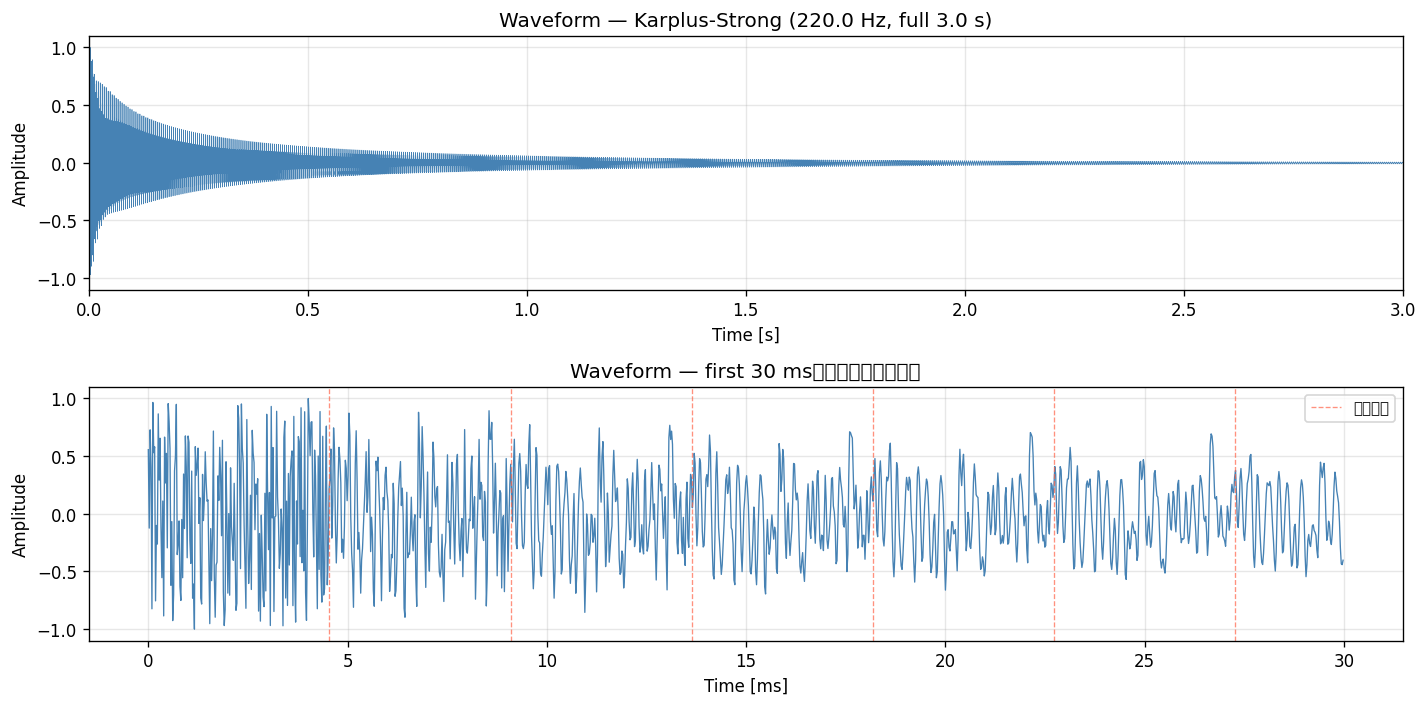

基本周期（理論値）: 4.55 ms


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# --- 全体波形 ---
axes[0].plot(t, wave, linewidth=0.4, color='steelblue')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform — Karplus-Strong ({FREQ} Hz, full {DURATION} s)')
axes[0].set_xlim(0, DURATION)

# --- 先頭 30 ms 拡大（基本周期が見える） ---
zoom_ms = 30
zoom_n  = int(SAMPLE_RATE * zoom_ms / 1000)
axes[1].plot(t[:zoom_n] * 1000, wave[:zoom_n], linewidth=0.8, color='steelblue')
axes[1].set_xlabel('Time [ms]')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Waveform — first {zoom_ms} ms（基本周期の確認）')

# 理論的な基本周期を縦線で示す
period_ms = 1000 / FREQ
for n in range(1, int(zoom_ms / period_ms) + 1):
    axes[1].axvline(n * period_ms, color='tomato', linestyle='--',
                    linewidth=0.8, alpha=0.7, label='基本周期' if n == 1 else '')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'waveform.png', bbox_inches='tight')
plt.show()
print(f'基本周期（理論値）: {period_ms:.2f} ms')

---

## 3. FFT スペクトル解析（周波数領域）

高速フーリエ変換（FFT）で時間領域の波形を周波数領域に変換する。これにより、

- **基音（第1倍音）** の周波数と強さ
- **倍音列（第2・第3・…倍音）** の存在と減衰度合い
- **音色の特徴**（倍音が豊か ← Karplus-Strong の特徴）

が分かる。

### 注意点
- FFT は **全区間の平均的なスペクトル** を返す。減衰する音の場合は早い時刻・遅い時刻のスペクトルが混ざる。
- 周波数分解能 `Δf = Fs / N`。精度を上げるには長い窓が必要。
- 窓関数（Hann窓など）を適用するとスペクトル漏れを抑えられる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/1110751291.py:40: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/1110751291.py:40: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/1110751291.py:40: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/1110751291.py:40: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/1110751291.py:40: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsb

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/resear

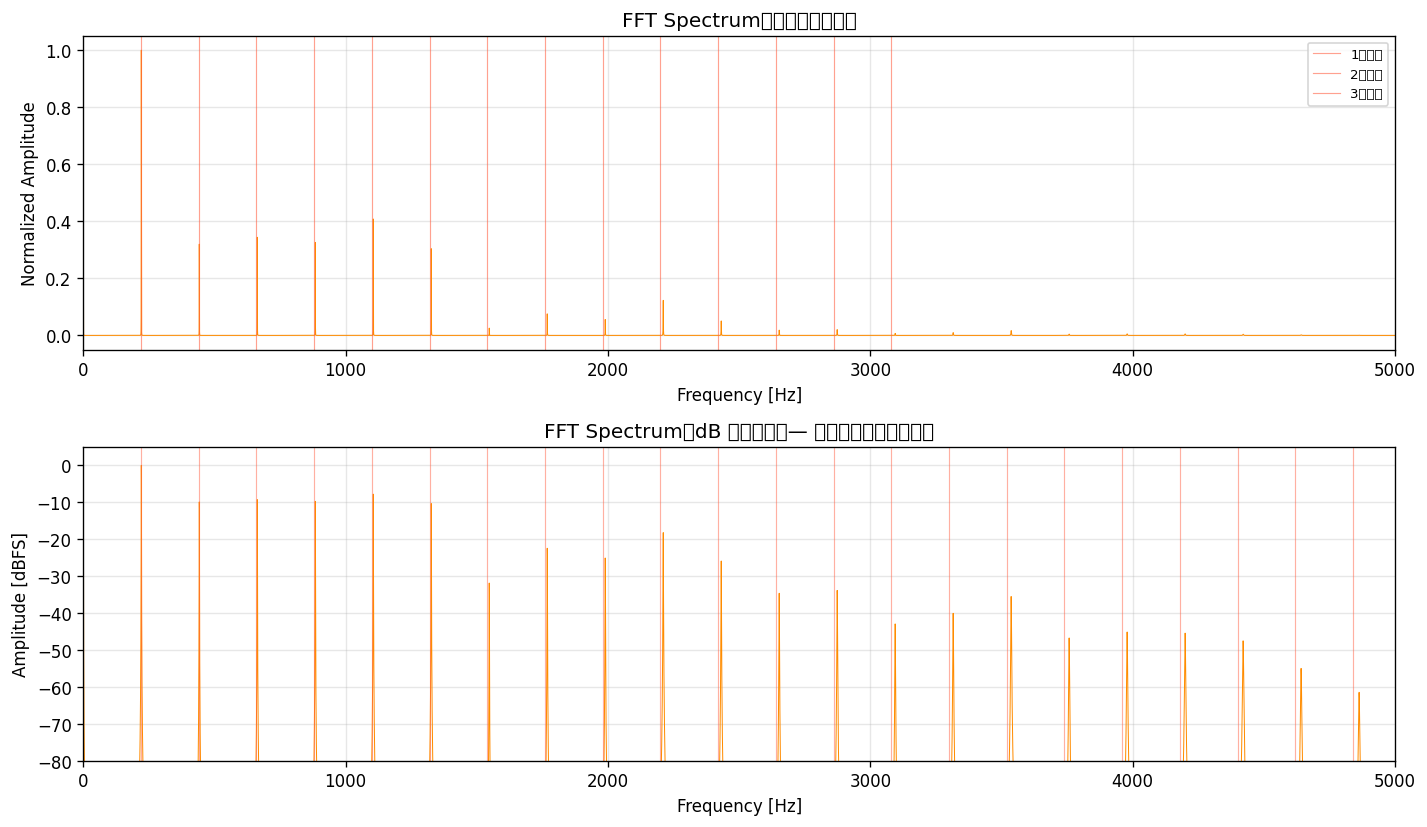

In [4]:
# Hann 窓を適用して FFT
window   = np.hanning(len(wave))
spectrum = np.abs(rfft(wave * window))
freqs    = rfftfreq(len(wave), 1 / SAMPLE_RATE)

# dB 変換（-120 dB でフロア）
spectrum_db = 20 * np.log10(np.maximum(spectrum / np.max(spectrum), 1e-6))

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# --- 線形スケール（倍音の存在が視覚的に明確） ---
axes[0].plot(freqs, spectrum / np.max(spectrum), linewidth=0.6, color='darkorange')
axes[0].set_xlim(0, 5000)
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('Normalized Amplitude')
axes[0].set_title('FFT Spectrum（線形スケール）')

# 基音と倍音の位置をマーク
for h in range(1, 15):
    hfreq = FREQ * h
    if hfreq > 5000:
        break
    axes[0].axvline(hfreq, color='tomato', linewidth=0.7, alpha=0.6,
                    label=f'{h}次倍音' if h <= 3 else '')
axes[0].legend(loc='upper right', fontsize=8)

# --- dB スケール（弱い倍音まで見える） ---
axes[1].plot(freqs, spectrum_db, linewidth=0.6, color='darkorange')
axes[1].set_xlim(0, 5000)
axes[1].set_ylim(-80, 5)
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Amplitude [dBFS]')
axes[1].set_title('FFT Spectrum（dB スケール）— 弱い成分も確認できる')
for h in range(1, 25):
    hfreq = FREQ * h
    if hfreq > 5000:
        break
    axes[1].axvline(hfreq, color='tomato', linewidth=0.7, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fft_spectrum.png', bbox_inches='tight')
plt.show()

---

## 4. スペクトログラム（時間×周波数）

短時間フーリエ変換（STFT）を利用して、**時間とともにスペクトルがどう変化するか**を2次元で可視化する。横軸が時間、縦軸が周波数、色（明るさ）が強度を表す。

Karplus-Strong 音では以下のパターンが観察される：

- 高倍音は早く消える（ローパスフィルターの効果）
- 低次倍音は長く残る
- 倍音列が水平なスジとして現れる

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:31: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:31: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:31: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:31: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:31: UserWarning: Glyph 20493 (\N{CJK UNIFIED IDEOGRAPH-500D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:32: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'spectrogram.png', bbox_inches='tight')


/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:32: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'spectrogram.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:32: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'spectrogram.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:32: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'spectrogram.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2704290577.py:32: UserWarning: Glyph 20493 (\N{CJK UNIFIED IDEOGRAPH-500D}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'spectrogram.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_80

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25313 (\N{CJK UNIFIED IDEOGRAPH-62E1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


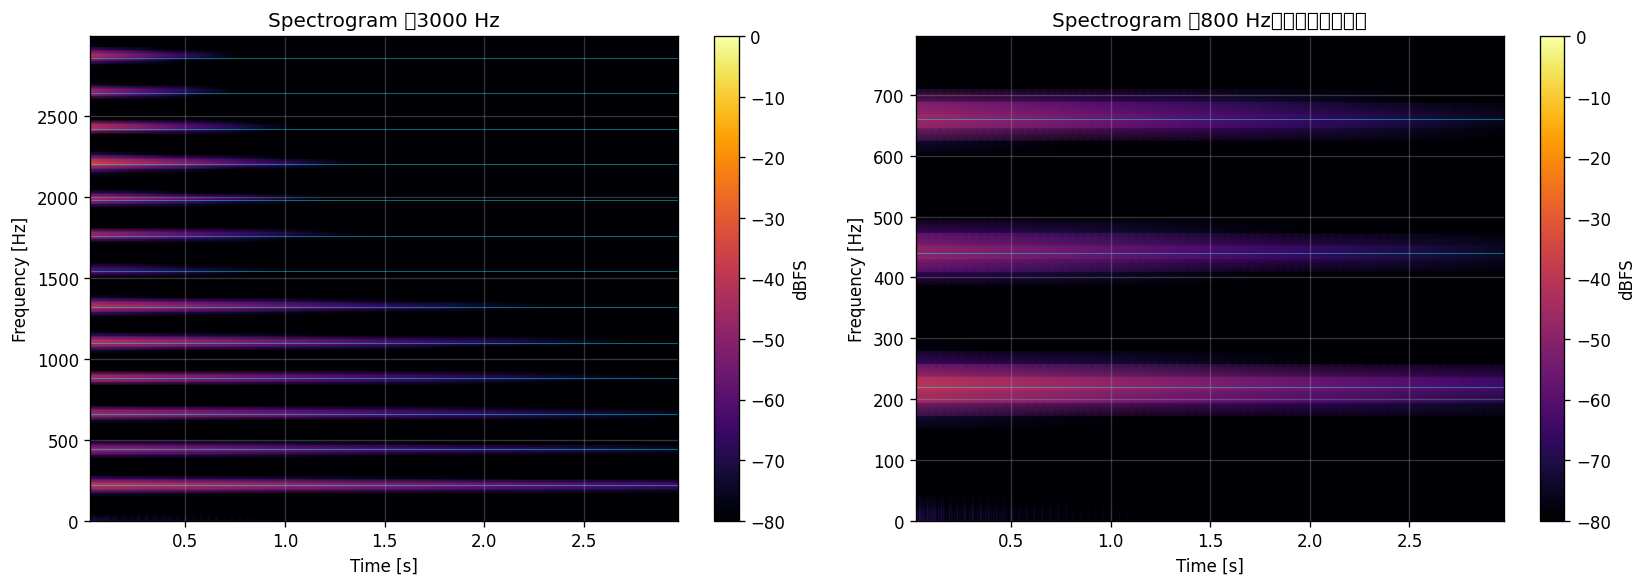

In [5]:
# STFT パラメータ
NPERSEG  = 2048   # 窓サイズ（周波数分解能と時間分解能のトレードオフ）
NOVERLAP = 1792   # オーバーラップ（NPERSEG の 7/8）

f_sg, t_sg, Sxx = spectrogram(
    wave, fs=SAMPLE_RATE,
    nperseg=NPERSEG, noverlap=NOVERLAP,
    window='hann'
)

# dB変換
Sxx_db = 10 * np.log10(np.maximum(Sxx, 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fmax, title) in zip(axes, [(3000, '〜3000 Hz'), (800, '〜800 Hz（低次倍音拡大）')]):
    freq_mask = f_sg <= fmax
    im = ax.pcolormesh(
        t_sg, f_sg[freq_mask], Sxx_db[freq_mask],
        shading='gouraud', cmap='inferno', vmin=-80, vmax=0
    )
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Frequency [Hz]')
    ax.set_title(f'Spectrogram {title}')
    plt.colorbar(im, ax=ax, label='dBFS')

    # 倍音位置に水平線
    for h in range(1, int(fmax / FREQ) + 1):
        ax.axhline(FREQ * h, color='cyan', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / 'spectrogram.png', bbox_inches='tight')
plt.show()

---

## 5. RMS エンベロープ

RMS（Root Mean Square）をフレームごとに計算することで、音量の時間変化（エンベロープ）を滑らかに可視化できる。

プラック音の特徴である**即時アタック → 指数的減衰**のパターンを定量的に確認できる。  
対数スケールで見ると、Karplus-Strong の減衰が線形（dB/s）になることが確認できる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2955732093.py:43: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2955732093.py:43: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2955732093.py:43: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2955732093.py:43: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2955732093.py:43: UserWarning: Glyph 28187 (\N{CJK UNIFIED IDEOGRAPH-6E1B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mk

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28187 (\N{CJK UNIFIED IDEOGRAPH-6E1B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/

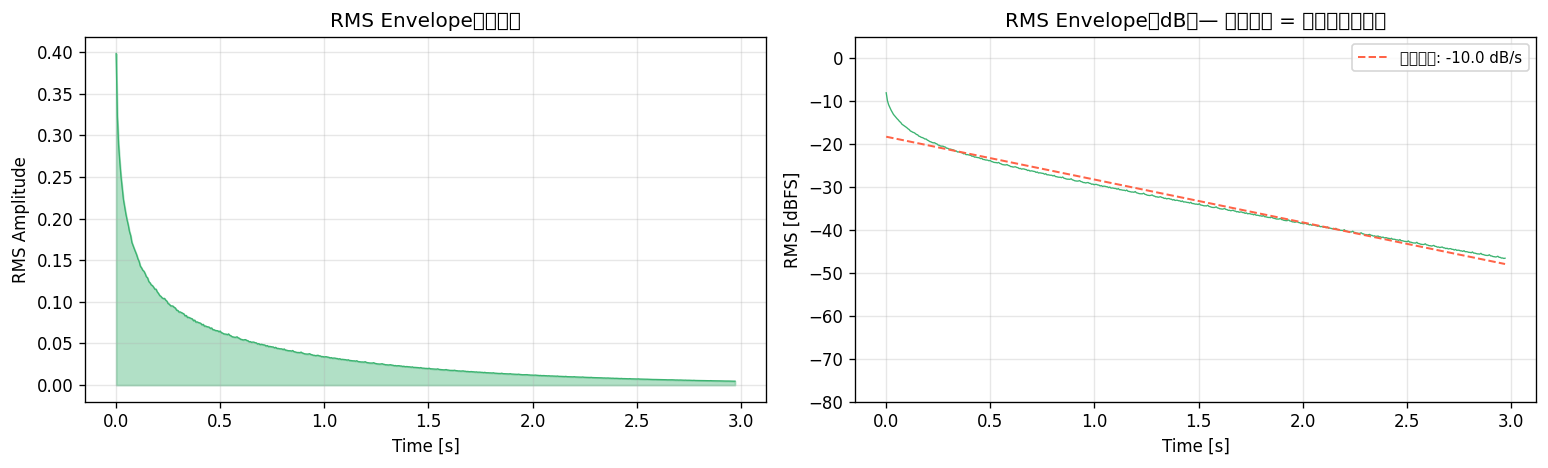

減衰レート（近似）: -9.98 dB/s


In [6]:
def rms_envelope(signal: np.ndarray, frame_size: int, hop_size: int) -> tuple[np.ndarray, np.ndarray]:
    """フレームごとの RMS を計算する"""
    n_frames = (len(signal) - frame_size) // hop_size + 1
    rms = np.array([
        np.sqrt(np.mean(signal[i * hop_size : i * hop_size + frame_size] ** 2))
        for i in range(n_frames)
    ])
    times = np.arange(n_frames) * hop_size / SAMPLE_RATE
    return times, rms


FRAME  = 1024
HOP    = 256
t_env, rms = rms_envelope(wave, FRAME, HOP)
rms_db = 20 * np.log10(np.maximum(rms, 1e-6))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- 線形 ---
axes[0].fill_between(t_env, rms, alpha=0.4, color='mediumseagreen')
axes[0].plot(t_env, rms, linewidth=0.8, color='mediumseagreen')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('RMS Amplitude')
axes[0].set_title('RMS Envelope（線形）')

# --- 対数（dB） ---
axes[1].plot(t_env, rms_db, linewidth=0.8, color='mediumseagreen')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('RMS [dBFS]')
axes[1].set_title('RMS Envelope（dB）— 線形減衰 = 指数減衰の確認')
axes[1].set_ylim(-80, 5)

# dB/s の近似直線
valid = rms_db > -60
if valid.sum() > 10:
    coeffs = np.polyfit(t_env[valid], rms_db[valid], 1)
    t_fit  = np.linspace(t_env[valid][0], t_env[valid][-1], 200)
    axes[1].plot(t_fit, np.polyval(coeffs, t_fit),
                 '--', color='tomato', linewidth=1.2,
                 label=f'近似直線: {coeffs[0]:.1f} dB/s')
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'rms_envelope.png', bbox_inches='tight')
plt.show()
print(f'減衰レート（近似）: {coeffs[0]:.2f} dB/s')

---

## 6. 倍音解析

FFT スペクトルのピーク検出によって、倍音ごとの周波数と振幅を定量的に抽出する。

- **倍音比（振幅比）** — 音色の明るさや豊かさに直結する
- **倍音の誤差** — 理論値（`f₀ × n`）からのズレを確認できる（非調和性の指標）
- Karplus-Strong は整数倍音列を持ち、弦楽器らしい調和的な音色が確認できる

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/427724131.py:34: UserWarning: Glyph 20493 (\N{CJK UNIFIED IDEOGRAPH-500D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/427724131.py:34: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/427724131.py:34: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/427724131.py:34: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/427724131.py:34: UserWarning: Glyph 26908 (\N{CJK UNIFIED IDEOGRAPH-691C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3

  n  |  実測 [Hz]  |  理論値 [Hz]  |  誤差 [Hz]  |  振幅比
------------------------------------------------------------
   1 |     222.00  |       220.00  |    +2.000  | 1.0000
   2 |     442.00  |       440.00  |    +2.000  | 0.4193
   3 |     664.00  |       660.00  |    +4.000  | 0.4928
   4 |     884.00  |       880.00  |    +4.000  | 0.5872
   5 |    1106.00  |      1100.00  |    +6.000  | 0.7954
   6 |    1326.00  |      1320.00  |    +6.000  | 0.7919
   7 |    1548.00  |      1540.00  |    +8.000  | 0.0823
   8 |    1768.00  |      1760.00  |    +8.000  | 0.3381
   9 |    1990.00  |      1980.00  |   +10.000  | 0.3320
  10 |    2210.00  |      2200.00  |   +10.000  | 0.9455
  11 |    2432.00  |      2420.00  |   +12.000  | 0.4924
  12 |    2652.00  |      2640.00  |   +12.000  | 0.2172
  13 |    2874.00  |      2860.00  |   +14.000  | 0.3089
  14 |    3094.00  |      3080.00  |   +14.000  | 0.1250


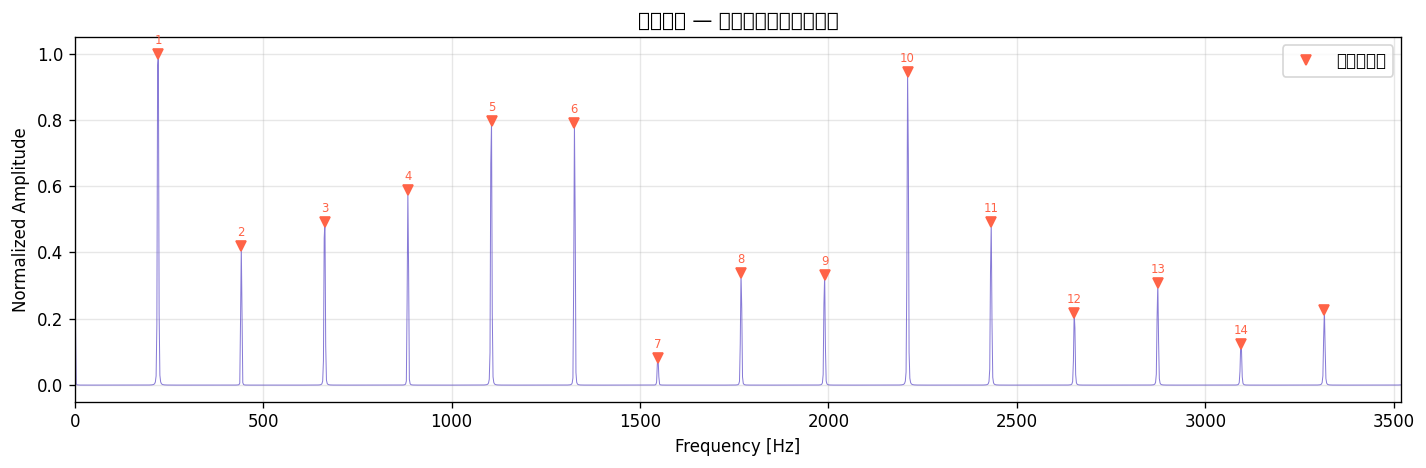

In [7]:
# 先頭 0.5 s だけを使う（エネルギーが集中している区間）
n_half  = int(SAMPLE_RATE * 0.5)
seg     = wave[:n_half] * np.hanning(n_half)
spec    = np.abs(rfft(seg))
fq      = rfftfreq(n_half, 1 / SAMPLE_RATE)

# ピーク検出（最小間隔: 基音の 70%、最小高さ: 全体の 1%）
min_dist = int(FREQ * 0.7 / (SAMPLE_RATE / n_half))
peaks, props = find_peaks(spec, distance=min_dist, height=spec.max() * 0.01)

# 倍音テーブル
print(f'  n  |  実測 [Hz]  |  理論値 [Hz]  |  誤差 [Hz]  |  振幅比')
print('-' * 60)
for rank, idx in enumerate(peaks[:14], start=1):
    measured  = fq[idx]
    theory    = FREQ * rank
    amp_ratio = spec[idx] / spec[peaks[0]]
    print(f'  {rank:2d} | {measured:10.2f}  | {theory:12.2f}  | {measured - theory:+9.3f}  | {amp_ratio:.4f}')

# グラフ
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fq, spec / spec.max(), linewidth=0.6, color='slateblue', alpha=0.8)
ax.plot(fq[peaks], spec[peaks] / spec.max(), 'v', color='tomato',
        markersize=6, label='検出ピーク')
for rank, idx in enumerate(peaks[:14], start=1):
    ax.annotate(f'{rank}', xy=(fq[idx], spec[idx] / spec.max()),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7, color='tomato')
ax.set_xlim(0, FREQ * 16)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Normalized Amplitude')
ax.set_title('倍音解析 — 検出された倍音ピーク')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'harmonics.png', bbox_inches='tight')
plt.show()

---

## 7. ゼロ交差率（ZCR）

ゼロ交差率（Zero Crossing Rate）は、単位時間あたりに波形が 0 をまたぐ回数。

- **値が高い** → 高周波成分が多い（アタック直後のノイズ的な部分）
- **値が低い** → 低周波の定常的な振動（サステイン部分）

Karplus-Strong のアタック〜サステイン遷移を時間軸上で捉えられる。  
音声認識では有声音・無声音の判定にも使われる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2984117790.py:29: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2984117790.py:29: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2984117790.py:29: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2984117790.py:29: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/2984117790.py:29: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_8000

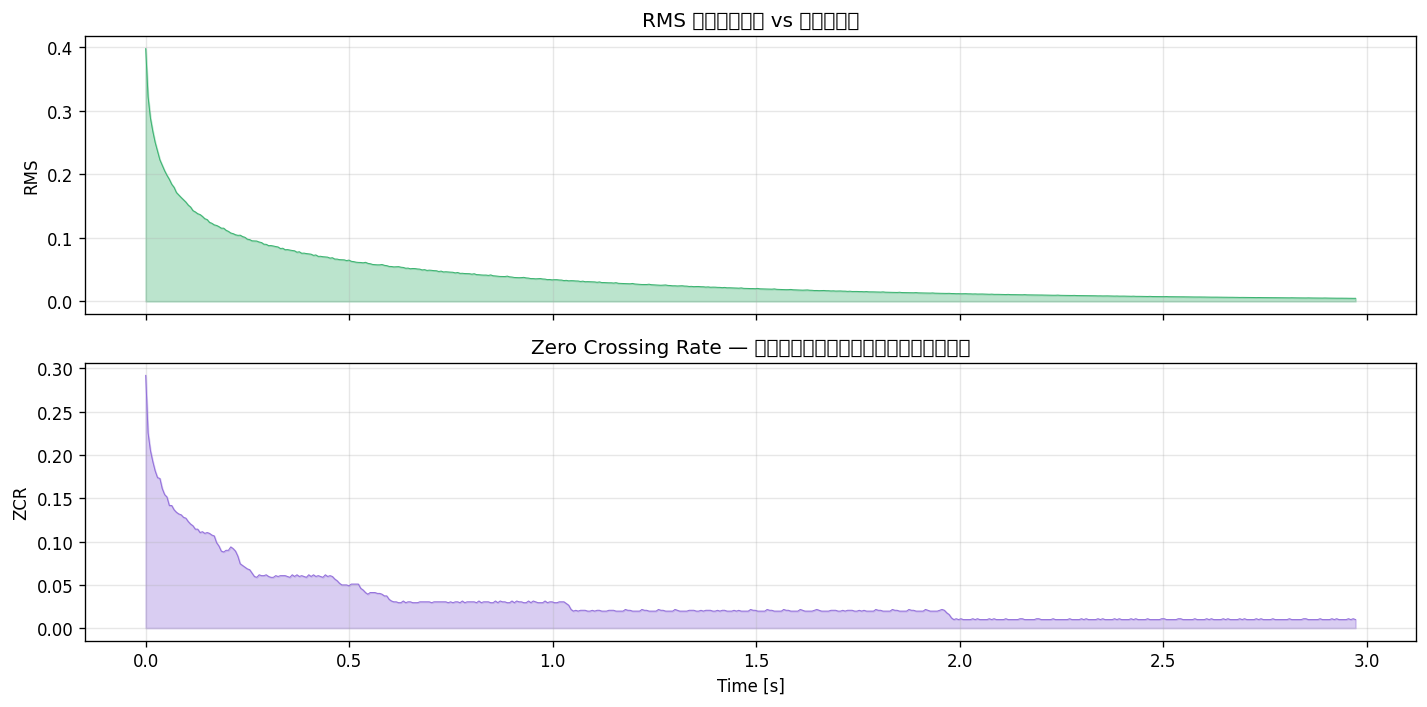

In [8]:
def zero_crossing_rate(signal: np.ndarray, frame_size: int, hop_size: int) -> tuple[np.ndarray, np.ndarray]:
    """フレームごとのゼロ交差率を計算する"""
    n_frames = (len(signal) - frame_size) // hop_size + 1
    zcr = np.array([
        np.sum(np.abs(np.diff(np.sign(
            signal[i * hop_size : i * hop_size + frame_size]
        )))) / (2 * frame_size)
        for i in range(n_frames)
    ])
    times = np.arange(n_frames) * hop_size / SAMPLE_RATE
    return times, zcr


t_zcr, zcr = zero_crossing_rate(wave, FRAME, HOP)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].fill_between(t_env, rms, alpha=0.35, color='mediumseagreen')
axes[0].plot(t_env, rms, linewidth=0.6, color='mediumseagreen')
axes[0].set_ylabel('RMS')
axes[0].set_title('RMS エンベロープ vs ゼロ交差率')

axes[1].fill_between(t_zcr, zcr, alpha=0.35, color='mediumpurple')
axes[1].plot(t_zcr, zcr, linewidth=0.6, color='mediumpurple')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('ZCR')
axes[1].set_title('Zero Crossing Rate — アタック直後に高く、サステインで低下')

plt.tight_layout()
plt.savefig(DATA_DIR / 'zcr.png', bbox_inches='tight')
plt.show()

---

## 8. ケプストラム分析と基本周波数推定

ケプストラム（Cepstrum）は `IFFT(log|FFT(x)|²)` で得られる変換で、スペクトルの周期構造を捉える。

「ケフレンシー」（quefrency）軸で倍音間隔に対応するピーク（ラームモニック）を検出することで、**基本周波数を推定**できる。

- 倍音が整数比で並んでいる場合、スペクトルは `f₀` 周期の繰り返し構造を持つ
- その周期 = ケプストラムのピーク位置 = `1/f₀` （秒）

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/3888269575.py:23: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/3888269575.py:23: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/3888269575.py:23: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/3888269575.py:23: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_63203/3888269575.py:23: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_6

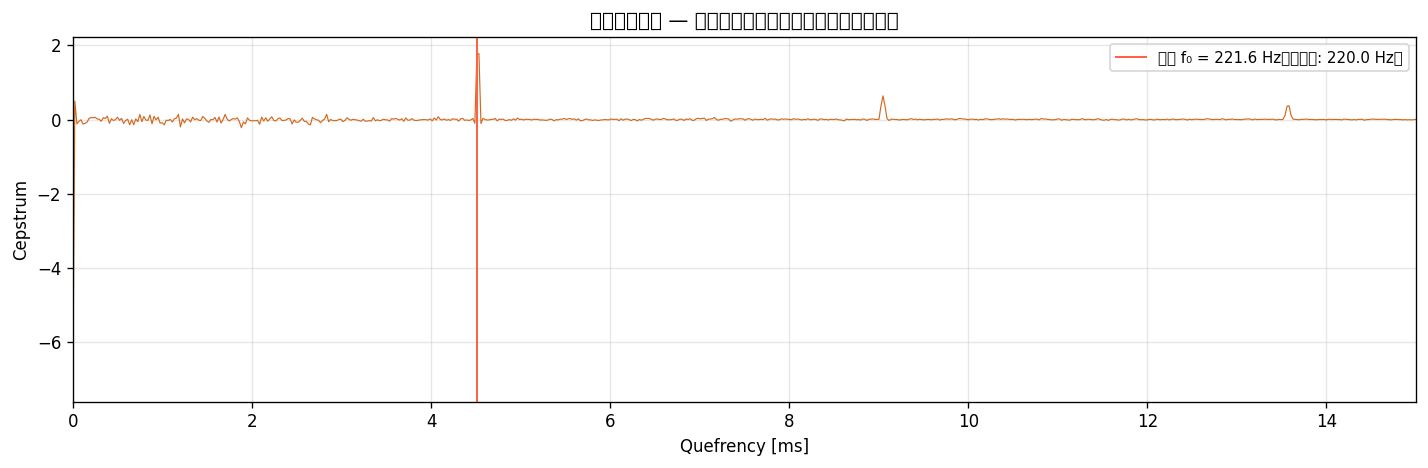

推定 f₀: 221.61 Hz  （理論値: 220.0 Hz，誤差: 1.61 Hz）


In [9]:
# 先頭 0.2 s を使用
n_seg  = int(SAMPLE_RATE * 0.2)
seg    = wave[:n_seg] * np.hanning(n_seg)
log_sp = np.log(np.abs(rfft(seg)) ** 2 + 1e-12)
cepst  = np.real(np.fft.irfft(log_sp))[:n_seg // 2]
quef   = np.arange(len(cepst)) / SAMPLE_RATE  # ケフレンシー [s]

# 基本周期範囲（50 Hz 〜 2000 Hz に対応するケフレンシー）
lo = int(SAMPLE_RATE / 2000)
hi = int(SAMPLE_RATE / 50)
peak_idx = lo + np.argmax(cepst[lo:hi])
f0_est   = 1.0 / quef[peak_idx]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(quef * 1000, cepst, linewidth=0.7, color='chocolate')
ax.axvline(quef[peak_idx] * 1000, color='tomato', linewidth=1.2,
           label=f'推定 f₀ = {f0_est:.1f} Hz（理論値: {FREQ} Hz）')
ax.set_xlim(0, 15)
ax.set_xlabel('Quefrency [ms]')
ax.set_ylabel('Cepstrum')
ax.set_title('ケプストラム — ラームモニックから基本周波数を推定')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'cepstrum.png', bbox_inches='tight')
plt.show()
print(f'推定 f₀: {f0_est:.2f} Hz  （理論値: {FREQ} Hz，誤差: {abs(f0_est - FREQ):.2f} Hz）')

---

## 9. まとめ — 音の解析フローと各手法の使い分け

### 解析フロー

```
生成・取得した音
  │
  ├─ 波形表示         → まず視覚的にエンベロープと基本周期を把握
  │
  ├─ RMS エンベロープ → アタック / ディケイ / サステイン / リリースの定量化
  │
  ├─ FFT スペクトル   → 周波数成分・倍音構造・音色の把握
  │
  ├─ スペクトログラム → 倍音の時間的変化・音の「育ち方」「消え方」
  │
  ├─ 倍音解析         → 倍音比の定量化・非調和性の確認
  │
  ├─ ZCR              → アタックの鋭さ・ノイズ成分の時間変化
  │
  └─ ケプストラム      → 基本周波数の推定・倍音の周期構造確認
```

### Karplus-Strong 音から確認できたこと

| 解析手法 | 観察結果 |
|---|---|
| 波形 | 急速なアタック後に指数的に振幅が減衰する |
| FFT | 基音 + 整数倍音列が均一間隔に並ぶ（調和的な音色） |
| スペクトログラム | 高倍音が早く消え、低次倍音が長く持続する |
| RMS エンベロープ | 対数スケールで線形に減衰（＝指数減衰）。減衰レートが `decay` 係数に対応 |
| ZCR | アタック直後に高く、その後急減 → ノイズ的アタックから調和振動への遷移を示す |
| ケプストラム | ケフレンシーピークから基本周波数を正確に推定できる |

### 次のステップ

- `decay` や `freq` を変えて各解析結果がどう変化するか比較する
- 複数の合成手法（FM合成、PCM、アディティブなど）の音と比較する
- MFCC（メル周波数ケプストラム係数）などの知覚的特徴量の解析に進む